# 多项式拟合

多项式拟合是一种曲线拟合方法，核心是通过构造一个多项式函数，让它尽可能地逼近一组给定的离散数据点，从而实现数据的趋势分析、插值或预测。
简单来说，就是找一条 “最优” 的多项式曲线，穿过或贴近所有数据点。

## 核心原理

给定一组离散数据点 $(x_1​,y_1​),(x_2​,y_2​),…,(x_n​,y_n​)$，多项式拟合的目标是找到一个 k 次多项式：

$$
y=a_0​+a_1​x+a_2​x_2+⋯+a_k​x_k
$$

其中 $a_0​,a_1​,…,a_k$​ 是多项式的系数，k 是多项式的阶数（degree）。
为了让这个多项式尽可能贴合数据，我们通常采用 最小二乘法：

计算每个数据点的真实值 $yi​$ 与多项式预测值 $y_​i^,$​ 的误差平方和 S；
找到一组系数 a0​∼ak​，使得 S 最小：
$$
S=\sum i= \frac 1 n ​(y_i​−y_​i^,​)^2= \sum_{i=1}^{n}​(y_i​−\sum_{j=0}^{k​}a_j​x_i^j​)^2→min
$$

## 关键概念

### （1）多项式阶数 k 的选择

+ 阶数太低：拟合曲线过于简单，无法捕捉数据的趋势，会出现 欠拟合；
+ 阶数太高：曲线会过度贴合每个数据点（包括噪声），出现 过拟合，泛化能力差；
+ 经验选择：阶数 k 一般远小于数据点数量 n（通常 k < n/5），可通过交叉验证确定最优阶数。

### （2）线性 vs 非线性拟合

多项式拟合的系数求解过程是线性的（因为误差平方和 S 是关于系数 aj​ 的线性函数），因此它属于 线性拟合 的范畴；
但拟合出来的曲线可以是曲线（比如二次多项式 $y=a_0​+a_1​x+a_2​x_2$ 是抛物线），这是 “线性拟合” 和 “曲线拟合” 的区别。


## 应用场景

+ 数据趋势分析：比如根据历史温度数据拟合多项式，分析温度变化趋势；
+ 缺失值填充 / 插值：用拟合的多项式预测数据点之间的未知值；
+ 传感器数据降噪：通过拟合平滑掉数据中的噪声；
+ 工程与科研建模：比如 SLAM 中激光雷达点云的边缘拟合、感知任务中目标轮廓的拟合。


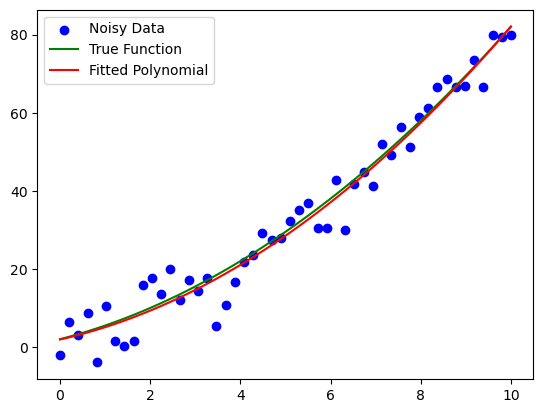

Fitted coefficients (a, b, c): [0.54019281 2.61299581 1.93093046]
Fitted polynomial function:
         2
0.5402 x + 2.613 x + 1.931


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成带有噪音的数据
x = np.linspace(0, 10, 50)                    # linspace(start, stop, num) 在指定的区间内生成均匀分布的数值序列。
y_true = 2 + 3 * x + 0.5 * x**2               # 真实的二次函数关系
y_noise = y_true + np.random.normal(0, 5, 50) # np.random.normal(loc=0, scale=1, size=None) 正态分布（高斯分布）随机数的函数

# 2. 多项式拟合：拟合2次多项式，返回系数 a, b, c
coefficients = np.polyfit(x, y_noise, 2)      # coefficients = [a, b, c] 对应于 ax^2 + bx + c
poly_func = np.poly1d(coefficients)           # 生成多项式函数对象
y_fit = poly_func(x)

# 3. 可视化结果
plt.scatter(x, y_noise, label='Noisy Data', color='blue')  # 绘制带噪音的数据点
plt.plot(x, y_true, label='True Function', color='green')   # 绘制真实函数曲线
plt.plot(x, y_fit, label='Fitted Polynomial', color='red')  # 绘制拟合多项式曲线
plt.legend()
plt.show()

print("Fitted coefficients (a, b, c):", coefficients)
print("Fitted polynomial function:\n", poly_func)